In [1]:
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

client = OpenAI()

response = client.responses.create(
    model="gpt-4.1",
    input="오늘 서울 날씨를 100자 내외로 알려줘",
    tools=[
        {
            "type": "web_search"  # 내장 도구
        }
    ]
)

print(response.output)             # ResponseFunctionWebSearch

[ResponseFunctionWebSearch(id='ws_0898cd7879f9a8810069bce2d042808193a76101f2b9fef07d', action=ActionSearch(query='오늘 서울 날씨', type='search', queries=['오늘 서울 날씨'], sources=None), status='completed', type='web_search_call'), ResponseOutputMessage(id='msg_0898cd7879f9a8810069bce2d0e0d48193b23601f4fbe9d3eb', content=[ResponseOutputText(annotations=[], text='오늘(2026년\u202f3월\u202f20일) 서울 날씨를 요약해 드립니다.\n\n현재 맑고 기온은 약 14\u202f°C (56\u202f°F)입니다. 오후 내내 햇살이 이어지고, 늦은 오후부터는 기온이 점차 내려갑니다. 특히 저녁에는 9\u202f°C 안팎으로 쌀쌀해지며 밤에는 영상~영하권에 이를 수 있습니다. 외출 시 겉옷 챙기시는 것이 좋겠습니다!', type='output_text', logprobs=[])], role='assistant', status='completed', type='message', phase=None)]


In [2]:
for item in response.output:
    print("==========================")
    if item.type == 'web_search_call':
        # item.action.query : 모델이 자동 생성한 검색어
        print(item.action.query)

    # message : 모델이 사용자에게 돌려주는 실제 답변 메시지
    elif item.type == 'message':
        print(item.content[0].annotations)
        print(item.content[0].text)

오늘 서울 날씨
[]
오늘(2026년 3월 20일) 서울 날씨를 요약해 드립니다.

현재 맑고 기온은 약 14 °C (56 °F)입니다. 오후 내내 햇살이 이어지고, 늦은 오후부터는 기온이 점차 내려갑니다. 특히 저녁에는 9 °C 안팎으로 쌀쌀해지며 밤에는 영상~영하권에 이를 수 있습니다. 외출 시 겉옷 챙기시는 것이 좋겠습니다!


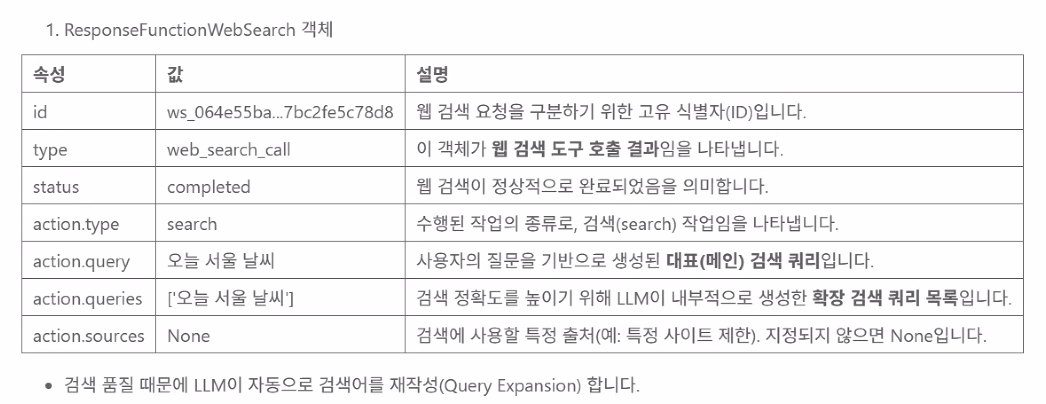

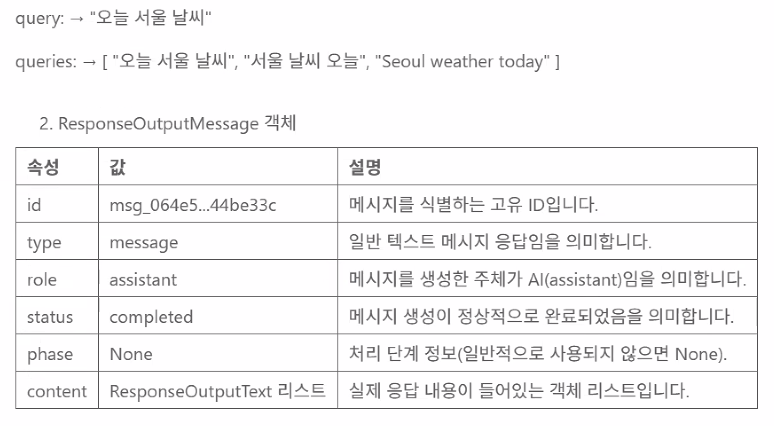

| 속성          | 값                                                                                                       | 설명                                  |
| ----------- | ------------------------------------------------------------------------------------------------------- | ----------------------------------- |
| type        | output_text                                                                                             | 이 콘텐츠가 텍스트 출력임을 의미합니다.              |
| text        | 오늘, 즉 2026년 3월 19일 서울의 현재 날씨는.<br> 맑고 기온은 약 6°C (42°F)입니다.<br> 밤사이에도 맑은 상태가 이어지며, .<br>새벽에는 기온이 1~4°C 수준까지 떨어질 전망입니다. | 사용자에게 전달된 실제 응답 텍스트입니다.             |
| annotations | []                                                                                                      | 텍스트에 대한 추가 정보(출처, 강조 등). 현재는 없음입니다. |
| logprobs    | []                                                                                                      | 토큰 생성 확률 정보(디버깅/분석용). 현재는 비어 있음입니다. |

In [3]:
# item.action.query : 모델이 자동 생성한 검색어
print(response.output[0].action.query )

오늘 서울 날씨
